# 💊 6. Salud: Consumo SPA (FACTOR DE RIESGO)

👉 Identifica zonas y poblaciones con mayor riesgo de drogadicción al ser este un co-factor de las ideaciones suicidas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

### Carga de Datos Preprocesados

In [9]:
import os

BASE_DIR = r'C:\Users\Latitude\Documents\V Semestre\DATAJAM\DATAJAM-DATAFONO_2026\datajam-2026-bogota'
PROCESSED_DIR = os.path.join(BASE_DIR, '01_datos', 'processed')

file_path = os.path.join(PROCESSED_DIR, 'p_salud_consumo.csv')

df_spa = pd.read_csv(file_path)
print(f'Total de registros cargados: {len(df_spa):,}')
display(df_spa.head(3))

Total de registros cargados: 97,545


,ano,sexo,nombrelocalidadresidencia,mesnotificacion,trimestre,tipoaseguramiento,sitiohabitualconsumo_vivienda,sitiohabitualconsumo_parque,sitiohabitualconsumo_est_educativo,sitiohabitualconsumo_bares_tabernas,...,sitiohabitualconsumo_casa_amigos,niveleducativo,curso_de_vida,comoacudiotratamiento,pertenenciaetnica,orientsexual,paisnacionalidad,nombreupz,estadocivil,casos
0,2022,Hombre,Kennedy,6,2,Subsidiado,NO,NO,NO,NO,...,SI,Secundaria completa,Juventud,Voluntariamente,Otros,Heterosexual,Sin Dato,AMERICAS,Soltero (a),1
1,2022,Hombre,Mártires,6,2,Subsidiado,SI,NO,NO,NO,...,NO,Secundaria completa,Adultez,Voluntariamente,Otros,Heterosexual,Sin Dato,LA SABANA,Soltero (a),2
2,2022,Hombre,Kennedy,6,2,Contributivo,NO,SI,SI,NO,...,NO,Secundaria incompleta,Adolescencia,Voluntariamente,Otros,Heterosexual,Sin Dato,CALANDAIMA,Soltero (a),1


## 📈 Tendencia
**¿Aumenta el consumo históricamente?**

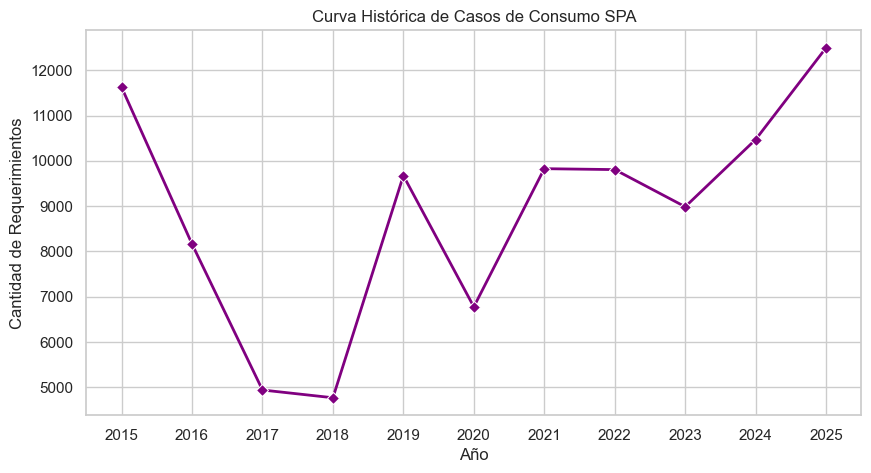

In [12]:
if 'ano' in df_spa.columns:
    tendencia = df_spa['ano'].value_counts().sort_index()
    plt.figure(figsize=(10,5))
    sns.lineplot(x=tendencia.index, y=tendencia.values, marker='D', color='purple', linewidth=2)
    plt.title('Curva Histórica de Casos de Consumo SPA')
    plt.xlabel('Año')
    plt.ylabel('Cantidad de Requerimientos')
    plt.xticks(tendencia.index)
    plt.show()

## 📍 Territorial
**¿Dónde es más alto el consumo / zonas críticas?**

C:\Users\Latitude\AppData\Local\Temp\ipykernel_21376\3534690626.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


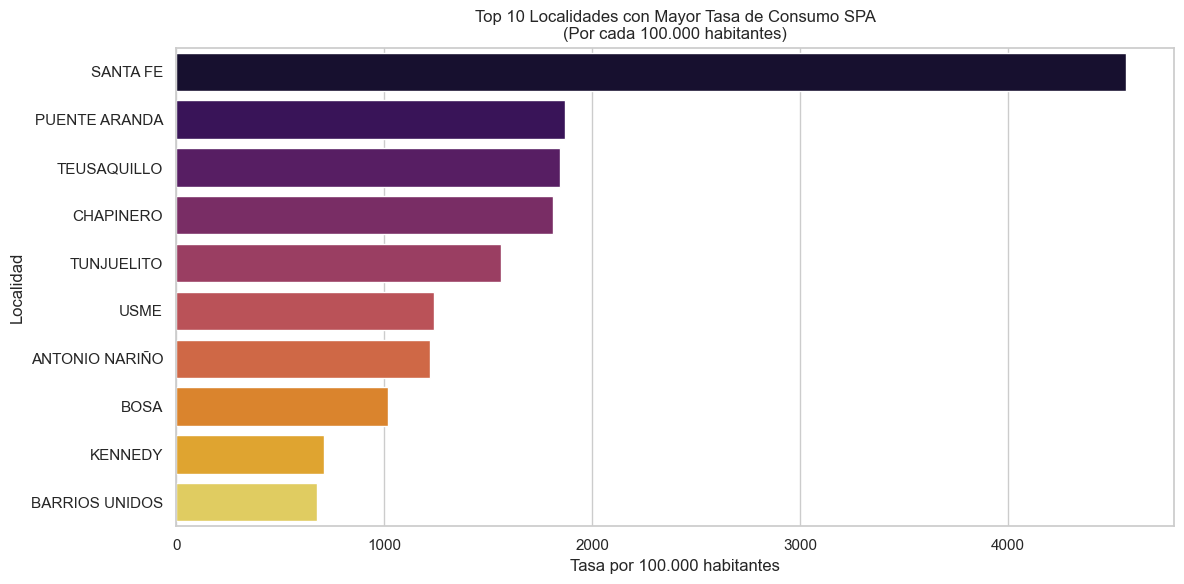

     localidad  casos  poblacion  tasa_por_100k
      SANTA FE   4984   109069.0    4569.584392
 PUENTE ARANDA   5286   282491.0    1871.210056
   TEUSAQUILLO   2813   152543.0    1844.070197
     CHAPINERO   2531   139701.0    1811.726473
    TUNJUELITO   3278   209784.0    1562.559585
          USME   5366   432724.0    1240.051395
ANTONIO NARIÑO   1353   110876.0    1220.282117
          BOSA   8522   836394.0    1018.897792
       KENNEDY   9040  1270438.0     711.565618
BARRIOS UNIDOS   1724   254462.0     677.507840


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Población estimada por localidad (Bogotá, fuente: proyecciones DANE 2023) ---
poblacion_localidades = {
    'USAQUEN': 507561,
    'CHAPINERO': 139701,
    'SANTA FE': 109069,
    'SAN CRISTOBAL': 416045,
    'USME': 432724,
    'TUNJUELITO': 209784,
    'BOSA': 836394,
    'KENNEDY': 1270438,
    'FONTIBON': 422367,
    'ENGATIVA': 890933,
    'SUBA': 1268179,
    'BARRIOS UNIDOS': 254462,
    'TEUSAQUILLO': 152543,
    'LOS MARTIRES': 100025,
    'ANTONIO NARIÑO': 110876,
    'PUENTE ARANDA': 282491,
    'LA CANDELARIA': 23550,
    'RAFAEL URIBE URIBE': 374246,
    'CIUDAD BOLIVAR': 726729,
    'SUMAPAZ': 6695,
}

if 'nombrelocalidadresidencia' in df_spa.columns:
    # Conteo de casos por localidad
    casos = df_spa['nombrelocalidadresidencia'].str.upper().value_counts()

    # Convertir a DataFrame
    df_ranking = casos.reset_index()
    df_ranking.columns = ['localidad', 'casos']

    # Unir con población
    df_ranking['poblacion'] = df_ranking['localidad'].map(poblacion_localidades)

    # Eliminar localidades sin datos de población
    df_ranking = df_ranking.dropna(subset=['poblacion'])

    # Calcular tasa por 100.000 habitantes
    df_ranking['tasa_por_100k'] = (df_ranking['casos'] / df_ranking['poblacion']) * 100_000

    # Ordenar por tasa y tomar top 10
    ranking_normalizado = df_ranking.nlargest(10, 'tasa_por_100k')

    # Graficar
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=ranking_normalizado,
        x='tasa_por_100k',
        y='localidad',
        palette='inferno'
    )
    plt.title('Top 10 Localidades con Mayor Tasa de Consumo SPA\n(Por cada 100.000 habitantes)')
    plt.xlabel('Tasa por 100.000 habitantes')
    plt.ylabel('Localidad')
    plt.tight_layout()
    plt.show()

    # Tabla comparativa opcional
    print(ranking_normalizado[['localidad', 'casos', 'poblacion', 'tasa_por_100k']].to_string(index=False))

## 📌 Contexto
**¿Dónde consumen (parques, vivienda, vía pública)?**

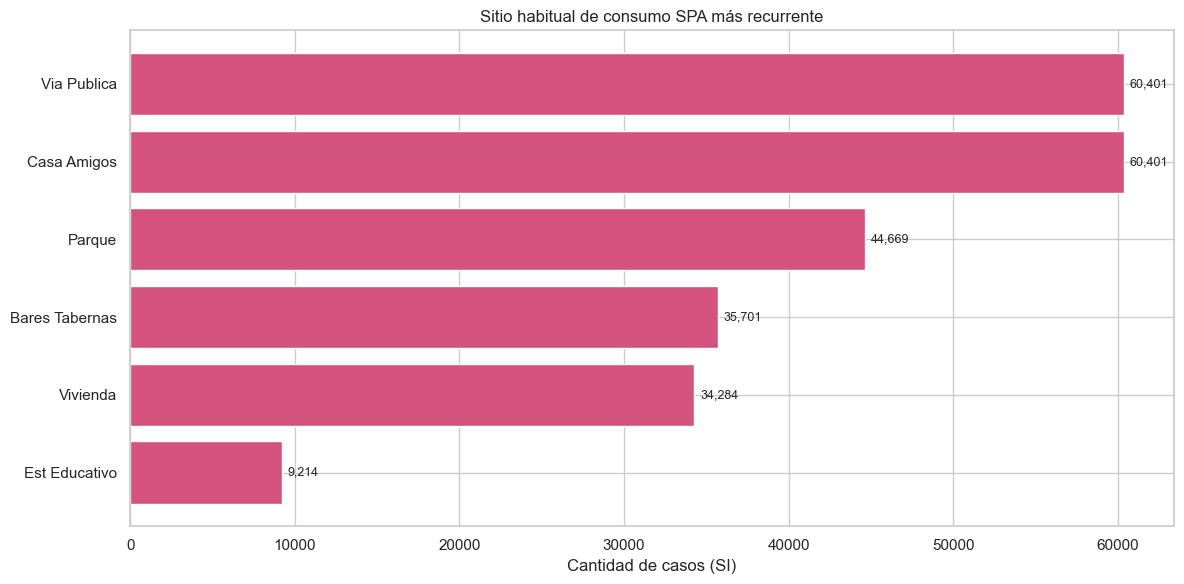

In [19]:
cols_contexto = [col for col in df_spa.columns if 'sitio' in col.lower()]

# Contar cuántos SI hay por columna
sumas_contexto = pd.Series({
    col: (df_spa[col].str.upper().str.strip() == 'SI').sum()
    for col in cols_contexto
}).sort_values(ascending=False)

# Limpiar etiquetas para la gráfica
etiquetas = sumas_contexto.index.str.replace('sitiohabitualconsumo_', '', regex=False).str.replace('_', ' ').str.title()

plt.figure(figsize=(12, 6))
bars = plt.barh(etiquetas[::-1], sumas_contexto.values[::-1], color='#D4537E')
plt.bar_label(bars, fmt='{:,.0f}', padding=4, fontsize=9)
plt.title('Sitio habitual de consumo SPA más recurrente')
plt.xlabel('Cantidad de casos (SI)')
plt.tight_layout()
plt.show()

## 👥 Perfil
**Edad / ciclo de vida y Sexo predominante**

In [21]:
if 'curso_de_vida' in df_spa.columns and 'SEXO' in df_spa.columns:
    plt.figure(figsize=(12,7))
    sns.countplot(data=df_spa, y='CURSO_DE_VIDA', hue='SEXO', palette='pastel', order=df_spa['CURSO_DE_VIDA'].value_counts().index)
    plt.title('Distribución de Consumidores por Curso de Vida y Sexo')
    plt.xlabel('Volumen de Casos')
    plt.ylabel('Curso de Vida')
    plt.show()

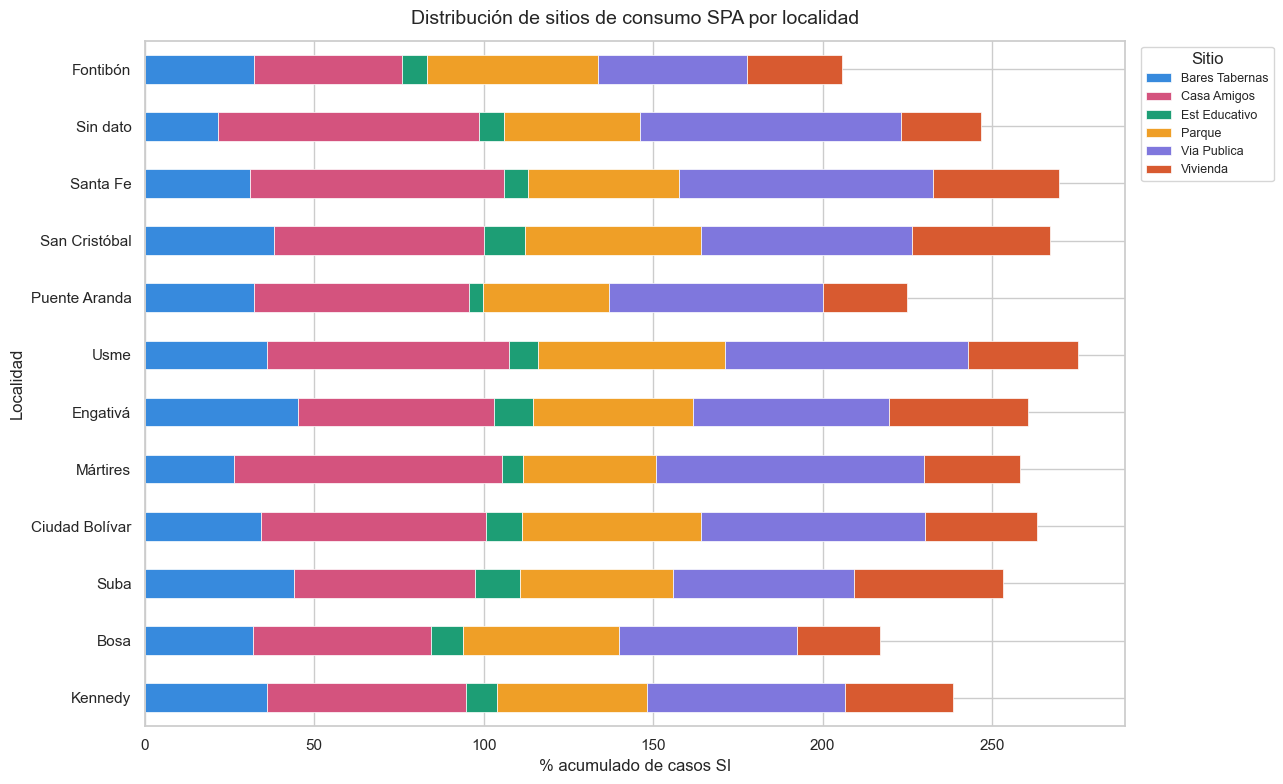

In [24]:
col_loc = 'nombrelocalidadresidencia'
cols_sitio = [col for col in df_spa.columns if 'sitio' in col.lower()]

# Calcular % de SI por localidad y sitio
registros = []
for col in cols_sitio:
    sitio = col.replace('sitiohabitualconsumo_', '').replace('_', ' ').title()
    grupo = df_spa.groupby(col_loc)[col].apply(
        lambda x: (x.str.upper().str.strip() == 'SI').sum() / len(x) * 100
    ).reset_index()
    grupo.columns = ['localidad', 'porcentaje']
    grupo['sitio'] = sitio
    registros.append(grupo)

df_plot = pd.concat(registros)

# Top 12 localidades
top_loc = df_spa[col_loc].value_counts().head(12).index
df_plot = df_plot[df_plot['localidad'].isin(top_loc)]
pivot = df_plot.pivot(index='localidad', columns='sitio', values='porcentaje').fillna(0)
pivot = pivot.loc[df_spa[col_loc].value_counts().head(12).index]

colors = ['#378ADD','#D4537E','#1D9E75','#EF9F27','#7F77DD','#D85A30']

ax = pivot.plot(kind='barh', stacked=True, figsize=(13, 8), color=colors, edgecolor='white', linewidth=0.5)
plt.title('Distribución de sitios de consumo SPA por localidad', fontsize=14, pad=12)
plt.xlabel('% acumulado de casos SI')
plt.ylabel('Localidad')
plt.legend(title='Sitio', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

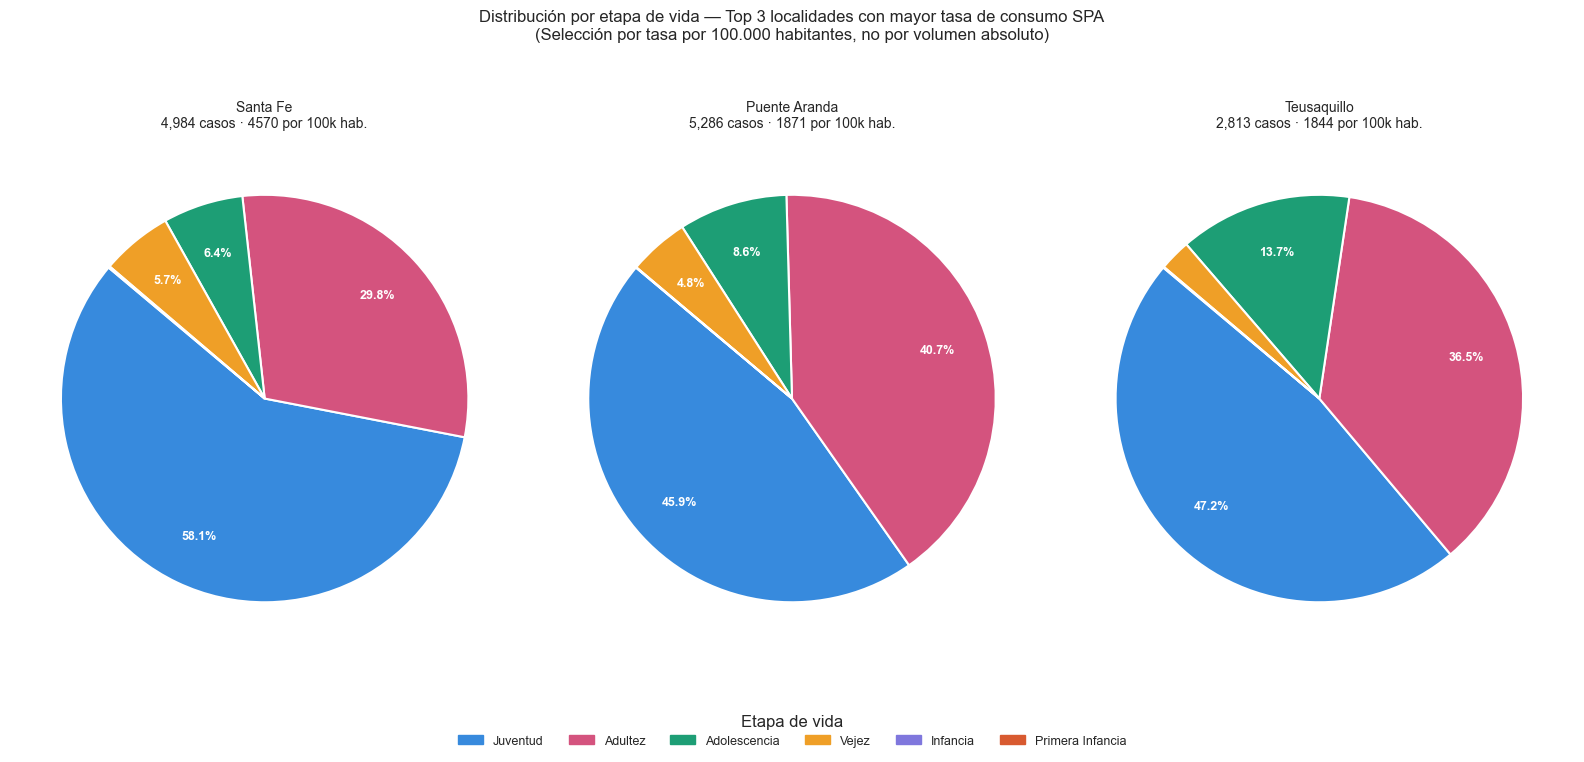

In [29]:
col_loc = 'nombrelocalidadresidencia'
col_vida = 'curso_de_vida'

# Población por localidad (DANE 2023)
poblacion_localidades = {
    'USAQUEN': 507561, 'CHAPINERO': 139701, 'SANTA FE': 109069,
    'SAN CRISTOBAL': 416045, 'USME': 432724, 'TUNJUELITO': 209784,
    'BOSA': 836394, 'KENNEDY': 1270438, 'FONTIBON': 422367,
    'ENGATIVA': 890933, 'SUBA': 1268179, 'BARRIOS UNIDOS': 254462,
    'TEUSAQUILLO': 152543, 'LOS MARTIRES': 100025, 'ANTONIO NARIÑO': 110876,
    'PUENTE ARANDA': 282491, 'LA CANDELARIA': 23550,
    'RAFAEL URIBE URIBE': 374246, 'CIUDAD BOLIVAR': 726729, 'SUMAPAZ': 6695,
}

colors = ['#378ADD','#D4537E','#1D9E75','#EF9F27','#7F77DD','#D85A30','#5DCAA5']

# --- Selección sin sesgo poblacional ---
casos = (
    df_spa[col_loc].str.upper().value_counts()
    .reset_index()
    .rename(columns={col_loc: 'localidad', 'count': 'casos'})
)
casos['poblacion'] = casos['localidad'].map(poblacion_localidades)
casos = casos.dropna(subset=['poblacion'])
casos['tasa_por_100k'] = (casos['casos'] / casos['poblacion']) * 100_000

top3 = casos.nlargest(3, 'tasa_por_100k')['localidad'].tolist()

# --- Gráfico ---
fig, axes = plt.subplots(1, 3, figsize=(16, 7))

for ax, localidad in zip(axes, top3):
    df_loc = df_spa[df_spa[col_loc].str.upper() == localidad]
    conteo = df_loc[col_vida].value_counts()

    fila = casos[casos['localidad'] == localidad].iloc[0]
    tasa = fila['tasa_por_100k']
    total = int(fila['casos'])

    wedges, texts, autotexts = ax.pie(
        conteo.values,
        labels=None,
        autopct=lambda p: f'{p:.1f}%' if p > 4 else '',
        colors=colors[:len(conteo)],
        startangle=140,
        wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'},
        pctdistance=0.75
    )
    for t in autotexts:
        t.set_fontsize(9)
        t.set_fontweight('bold')
        t.set_color('white')

    # Título con tasa visible para que el usuario entienda el criterio
    ax.set_title(
        f'{localidad.title()}\n{total:,} casos · {tasa:.0f} por 100k hab.',
        fontsize=10, fontweight='500', pad=12
    )

# Leyenda compartida
etapas = df_spa[col_vida].value_counts().index.tolist()
legend_elements = [
    plt.Rectangle((0,0),1,1, color=colors[i], label=etapas[i])
    for i in range(min(len(etapas), len(colors)))
]
fig.legend(
    handles=legend_elements, title='Etapa de vida',
    loc='lower center', ncol=len(etapas),
    bbox_to_anchor=(0.5, -0.05), fontsize=9, frameon=False
)

plt.suptitle(
    'Distribución por etapa de vida — Top 3 localidades con mayor tasa de consumo SPA\n'
    '(Selección por tasa por 100.000 habitantes, no por volumen absoluto)',
    fontsize=12, fontweight='500', y=1.02
)
plt.tight_layout()
plt.show()